# Feature Engineering Pipeline

Build features for three ML models, with feature selection analysis for each. Data is sourced from GCS with local fallback.

- **Model A**: Lap-level with tyre data (2019-2024, ~16 features)
- **Model B**: Lap-level without tyre data (2018-2025, ~11 features)
- **Model C**: Pre-race features (2018-2025, ~24 features)
- **Model D**: Stacking meta-model (no feature engineering — uses predictions from A, B, C)

All temporal features use shift(1) to prevent data leakage.

## 0. Setup & Data Loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

from f1_predictor.data.storage import load_from_gcs_or_local
from f1_predictor.features import (
    ExpandingWindowSplit,
    LeaveOneSeasonOut,
    build_lap_notyre_features,
    build_lap_tyre_features,
    build_race_features,
)

sns.set_theme(style="whitegrid")
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
for subdir in ["lap_tyre", "lap_notyre", "race"]:
    (DATA_PROCESSED / subdir).mkdir(parents=True, exist_ok=True)

In [2]:
laps = load_from_gcs_or_local(
    "data/raw/laps/all_laps.parquet", DATA_RAW / "laps" / "all_laps.parquet"
)
races = load_from_gcs_or_local(
    "data/raw/race/all_races.parquet", DATA_RAW / "race" / "all_races.parquet"
)
print(f"Laps: {laps.shape[0]:,} rows, {laps.shape[1]} columns")
print(f"Races: {races.shape[0]:,} rows, {races.shape[1]} columns")

Laps: 165,128 rows, 19 columns
Races: 3,458 rows, 36 columns


## 1. Model A — Lap Features WITH Tyre (2019-2024)

In [3]:
tyre_laps = laps[laps["season"].between(2019, 2024)]
tyre_complete = tyre_laps["tire_compound"].notna().mean()
print(f"Tyre data completeness (2019-2024): {tyre_complete:.1%}")
print(f"Rows with tyre data: {tyre_laps['tire_compound'].notna().sum():,}")

Tyre data completeness (2019-2024): 99.7%
Rows with tyre data: 139,962


In [4]:
features_a = build_lap_tyre_features(laps)
print(f"Model A features: {features_a.shape}")
print(f"Columns: {list(features_a.columns)}")
features_a.head()

Model A features: (139962, 27)
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'lap_number', 'lap_time_delta_race_median', 'lap_time_rolling_3', 'lap_time_rolling_5', 'position_change_from_lap1', 'gap_to_leader', 'gap_to_ahead', 'laps_since_last_pit', 'pit_stop_count', 'race_progress_pct', 'is_pit_in_lap', 'is_pit_out_lap', 'compound_HARD', 'compound_INTERMEDIATE', 'compound_MEDIUM', 'compound_SOFT', 'compound_WET', 'tire_life', 'stint', 'degradation_rate', 'compound_pace_delta', 'position']


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_delta_race_median,lap_time_rolling_3,lap_time_rolling_5,position_change_from_lap1,...,compound_HARD,compound_INTERMEDIATE,compound_MEDIUM,compound_SOFT,compound_WET,tire_life,stint,degradation_rate,compound_pace_delta,position
0,2019,1,Australian Grand Prix,ALB,Toro Rosso,1,NaN,NaN,NaN,0.0,...,0,0,0,1,0,1.0,1.0,NaN,NaN,11.0
1,2019,1,Australian Grand Prix,ALB,Toro Rosso,2,-9.72200,101.7590,101.75900,0.0,...,0,0,0,1,0,2.0,1.0,NaN,-2.0340,11.0
2,2019,1,Australian Grand Prix,ALB,Toro Rosso,3,-5.11175,96.7375,96.73750,0.0,...,0,0,0,1,0,3.0,1.0,NaN,-1.4435,11.0
3,2019,1,Australian Grand Prix,ALB,Toro Rosso,4,-0.07850,94.9440,94.94400,0.0,...,0,0,0,1,0,4.0,1.0,-5.2010,-0.6960,11.0
4,2019,1,Australian Grand Prix,ALB,Toro Rosso,5,-0.46550,91.4980,94.06325,0.0,...,0,0,0,1,0,5.0,1.0,-3.1373,-0.4490,11.0


In [5]:
print("Missing values per column:")
missing = features_a.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal complete rows: {features_a.dropna().shape[0]:,} / {features_a.shape[0]:,}")

Missing values per column:
lap_time_delta_race_median     4812
lap_time_rolling_3             2925
lap_time_rolling_5             2570
position_change_from_lap1       207
gap_to_leader                  2332
gap_to_ahead                   2376
tire_life                       321
degradation_rate              21399
compound_pace_delta             475
position                        207
dtype: int64

Total complete rows: 117,555 / 139,962


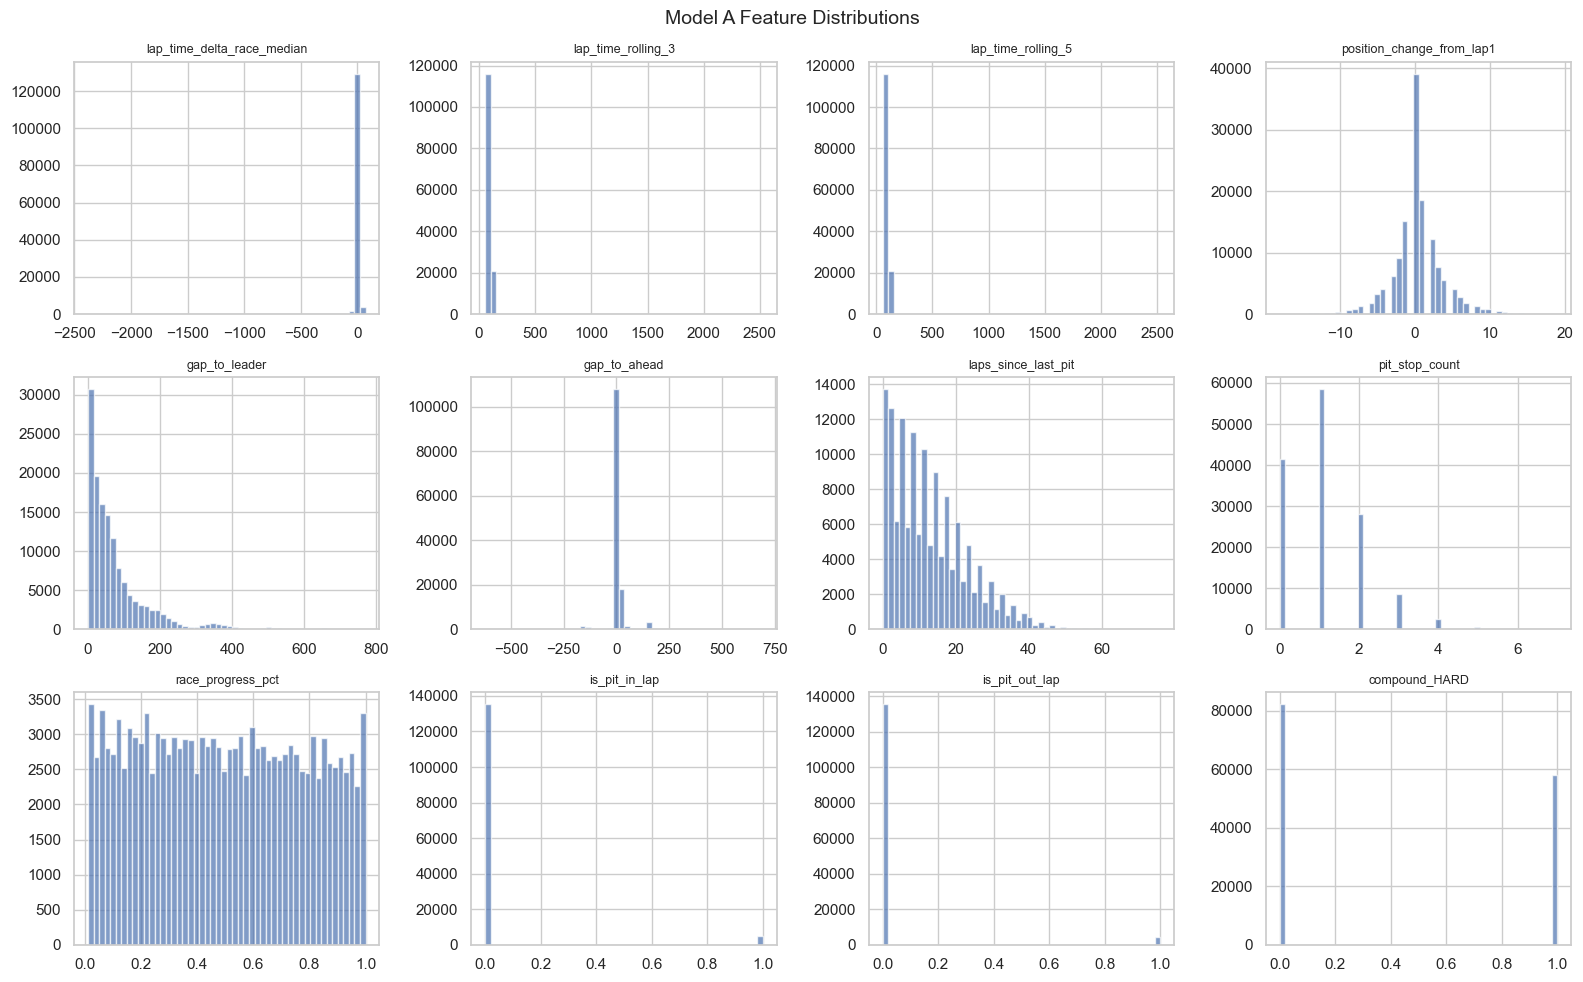

In [6]:
numeric_cols = features_a.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in numeric_cols if c not in ["season", "round", "lap_number", "position"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, feature_cols[:12]):
    features_a[col].dropna().hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(feature_cols[:12]):]:
    ax.set_visible(False)
fig.suptitle("Model A Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

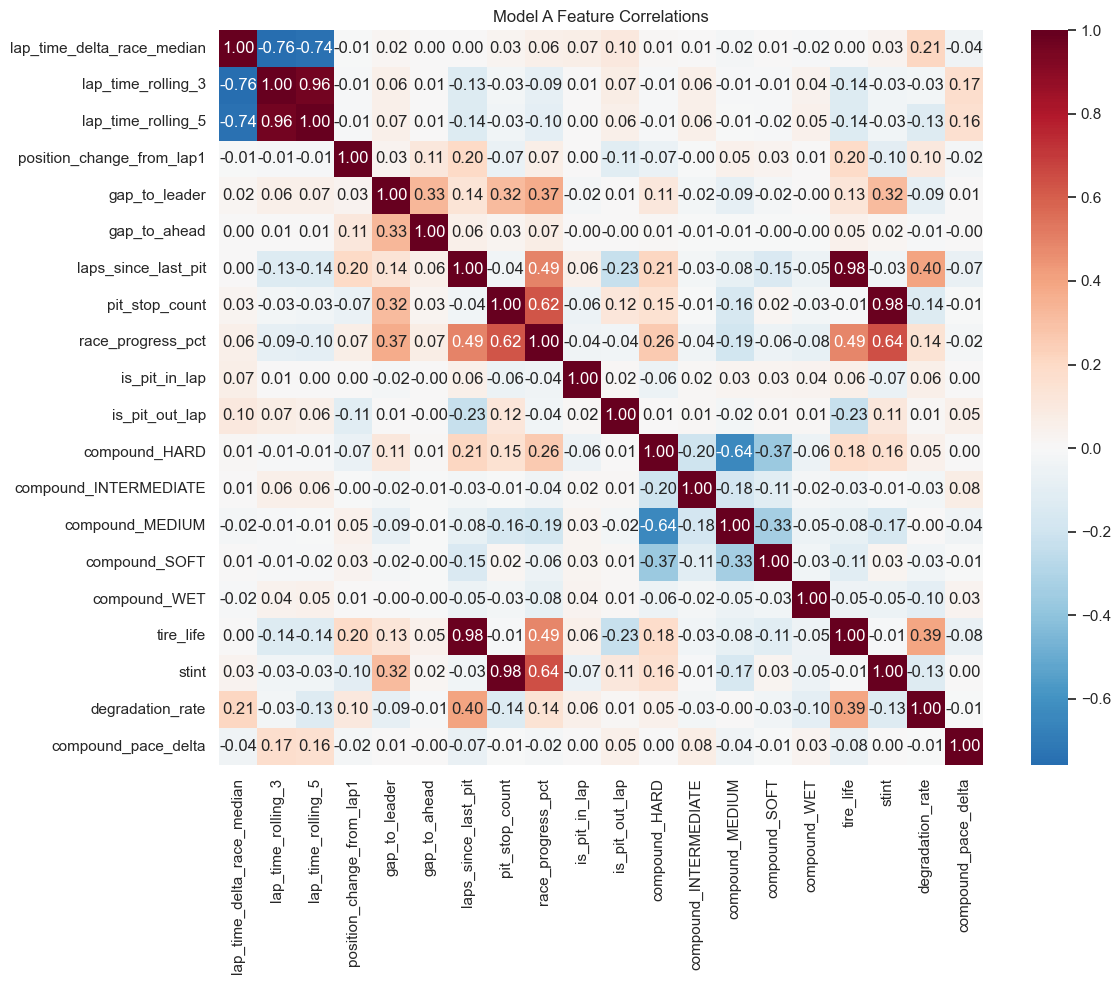

In [7]:
corr = features_a[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Model A Feature Correlations")
plt.tight_layout()
plt.show()

In [8]:
splitter_a = LeaveOneSeasonOut()
groups_a = features_a["season"].values
print(f"Model A CV: {splitter_a.get_n_splits()} folds (LOSO)")
for i, (train_idx, val_idx) in enumerate(splitter_a.split(groups_a)):
    train_seasons = sorted(set(groups_a[train_idx]))
    val_seasons = sorted(set(groups_a[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_a.get_test_split(groups_a)
print(f"  Test: seasons={sorted(set(groups_a[test_idx]))} ({len(test_idx):,})")

Model A CV: 5 folds (LOSO)
  Fold 1: train=[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] (89,680), val=[np.int64(2019)] (23,676)
  Fold 2: train=[np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)] (95,004), val=[np.int64(2020)] (18,352)
  Fold 3: train=[np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023)] (89,658), val=[np.int64(2021)] (23,698)
  Fold 4: train=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2023)] (90,113), val=[np.int64(2022)] (23,243)
  Fold 5: train=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (88,969), val=[np.int64(2023)] (24,387)
  Test: seasons=[np.int64(2024)] (26,606)


In [9]:
out_a = DATA_PROCESSED / "lap_tyre" / "features_laps_tyre.parquet"
features_a.to_parquet(out_a, index=False)
print(f"Saved: {out_a} ({out_a.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\lap_tyre\features_laps_tyre.parquet (5836 KB)


## 2. Model B — Lap Features WITHOUT Tyre (2018-2025)

In [10]:
features_b = build_lap_notyre_features(laps)
print(f"Model B features: {features_b.shape}")
print(f"Seasons: {sorted(features_b['season'].unique())}")
print(f"Columns: {list(features_b.columns)}")
features_b.head()

Model B features: (165128, 18)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'lap_number', 'lap_time_delta_race_median', 'lap_time_rolling_3', 'lap_time_rolling_5', 'position_change_from_lap1', 'gap_to_leader', 'gap_to_ahead', 'laps_since_last_pit', 'pit_stop_count', 'race_progress_pct', 'is_pit_in_lap', 'is_pit_out_lap', 'position']


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_delta_race_median,lap_time_rolling_3,lap_time_rolling_5,position_change_from_lap1,gap_to_leader,gap_to_ahead,laps_since_last_pit,pit_stop_count,race_progress_pct,is_pit_in_lap,is_pit_out_lap,position
0,2018,1,Australian Grand Prix,ALO,McLaren,1,NaN,NaN,NaN,0.0,7.295,0.963,0,0,0.017241,0,0,10.0
1,2018,1,Australian Grand Prix,ALO,McLaren,2,-10.17450,101.5280,101.5280,0.0,8.595,1.206,1,0,0.034483,0,0,10.0
2,2018,1,Australian Grand Prix,ALO,McLaren,3,-5.50025,96.5465,96.5465,0.0,10.090,1.243,2,0,0.051724,0,0,10.0
3,2018,1,Australian Grand Prix,ALO,McLaren,4,-1.31800,94.7990,94.7990,0.0,11.168,1.122,3,0,0.068966,0,0,10.0
4,2018,1,Australian Grand Prix,ALO,McLaren,5,0.33275,91.1400,93.7370,0.0,13.917,1.198,4,0,0.086207,0,0,10.0


Missing values per column:
lap_time_delta_race_median    6183
lap_time_rolling_3            3950
lap_time_rolling_5            3490
position_change_from_lap1      261
gap_to_leader                 2814
gap_to_ahead                  2864
position                       261
dtype: int64


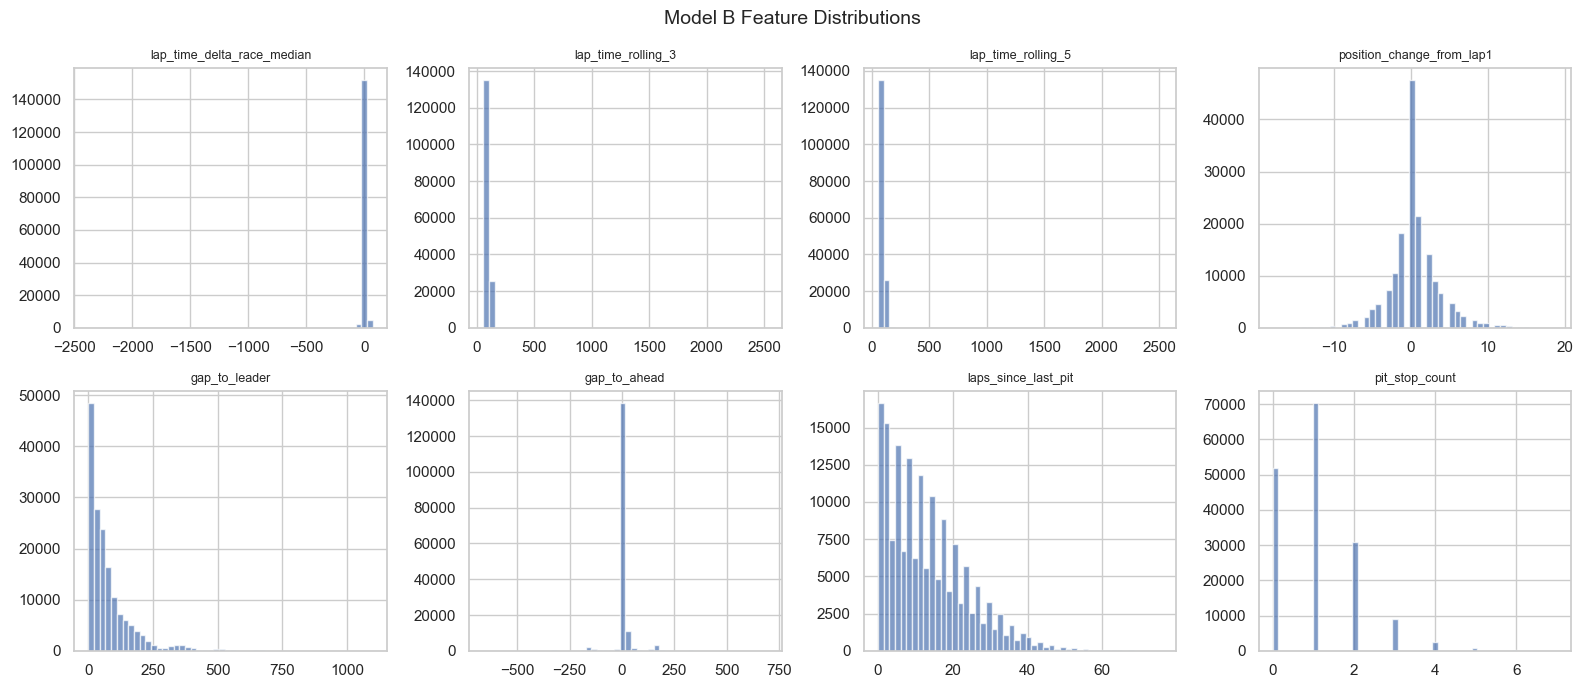

In [11]:
print("Missing values per column:")
missing_b = features_b.isnull().sum()
print(missing_b[missing_b > 0])

numeric_b = features_b.select_dtypes(include=[np.number]).columns
feature_cols_b = [c for c in numeric_b if c not in ["season", "round", "lap_number", "position"]]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, feature_cols_b[:8]):
    features_b[col].dropna().hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(feature_cols_b[:8]):]:
    ax.set_visible(False)
fig.suptitle("Model B Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
splitter_b = ExpandingWindowSplit()
groups_b = features_b["season"].values
print(f"Model B CV: {splitter_b.get_n_splits()} folds (expanding window)")
for i, (train_idx, val_idx) in enumerate(splitter_b.split(groups_b)):
    train_seasons = sorted(set(groups_b[train_idx]))
    val_seasons = sorted(set(groups_b[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_b.get_test_split(groups_b)
print(f"  Test: seasons={sorted(set(groups_b[test_idx]))} ({len(test_idx):,})")

Model B CV: 5 folds (expanding window)
  Fold 1: train=[np.int64(2018)] (22,337), val=[np.int64(2019)] (23,676)
  Fold 2: train=[np.int64(2018), np.int64(2019)] (46,013), val=[np.int64(2020)] (18,352)
  Fold 3: train=[np.int64(2018), np.int64(2019), np.int64(2020)] (64,365), val=[np.int64(2021)] (23,758)
  Fold 4: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] (88,123), val=[np.int64(2022)] (23,577)
  Fold 5: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (111,700), val=[np.int64(2023)] (24,422)
  Test: seasons=[np.int64(2025)] (2,400)


In [13]:
out_b = DATA_PROCESSED / "lap_notyre" / "features_laps_notyre.parquet"
features_b.to_parquet(out_b, index=False)
print(f"Saved: {out_b} ({out_b.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\lap_notyre\features_laps_notyre.parquet (4842 KB)


## 3. Model C — Pre-Race Features (2018-2025)

In [14]:
features_c = build_race_features(races)
print(f"Model C features: {features_c.shape}")
print(f"Seasons: {sorted(features_c['season'].unique())}")
print(f"Columns: {list(features_c.columns)}")
features_c.head()

Model C features: (3458, 33)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'best_quali_sec', 'quali_delta_to_pole', 'grid_position', 'quali_position_vs_teammate', 'avg_finish_last_3', 'avg_finish_last_5', 'points_last_3', 'points_cumulative_season', 'dnf_rate_season', 'position_trend', 'driver_circuit_avg_finish', 'driver_circuit_races', 'driver_circuit_podium_rate', 'driver_circuit_dnf_rate', 'team_avg_finish_last_3', 'team_points_cumulative_season', 'circuit_street', 'circuit_permanent', 'circuit_hybrid', 'circuit_avg_dnf_rate', 'weather_temp_max', 'weather_precip_mm', 'weather_wind_max_kph', 'is_wet_race', 'finish_position', 'is_podium', 'is_points_finish', 'is_dnf']


,season,round,event_name,driver_abbrev,team,best_quali_sec,quali_delta_to_pole,grid_position,quali_position_vs_teammate,avg_finish_last_3,...,circuit_hybrid,circuit_avg_dnf_rate,weather_temp_max,weather_precip_mm,weather_wind_max_kph,is_wet_race,finish_position,is_podium,is_points_finish,is_dnf
0,2018,1,Australian Grand Prix,ALO,McLaren,83.597,2.433,10.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,5.0,False,True,False
1,2018,1,Australian Grand Prix,BOT,Mercedes,82.089,0.925,15.0,14.0,NaN,...,1,NaN,23.4,5.2,39.8,1,8.0,False,True,False
2,2018,1,Australian Grand Prix,ERI,Sauber,84.556,3.392,17.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,19.0,False,False,True
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,85.295,4.131,20.0,4.0,NaN,...,1,NaN,23.4,5.2,39.8,1,18.0,False,False,True
4,2018,1,Australian Grand Prix,GRO,Haas F1 Team,83.339,2.175,6.0,1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,16.0,False,False,True


In [15]:
print("Missing values per column:")
missing_c = features_c.isnull().sum()
print(missing_c[missing_c > 0])

Missing values per column:
best_quali_sec                   1038
quali_delta_to_pole              1038
grid_position                       3
quali_position_vs_teammate          8
avg_finish_last_3                  43
avg_finish_last_5                  43
points_last_3                      43
points_cumulative_season          173
dnf_rate_season                   173
position_trend                    126
driver_circuit_avg_finish        1070
driver_circuit_races             1070
driver_circuit_podium_rate       1070
driver_circuit_dnf_rate          1070
team_avg_finish_last_3             42
team_points_cumulative_season     162
circuit_avg_dnf_rate              620
finish_position                     3
dtype: int64


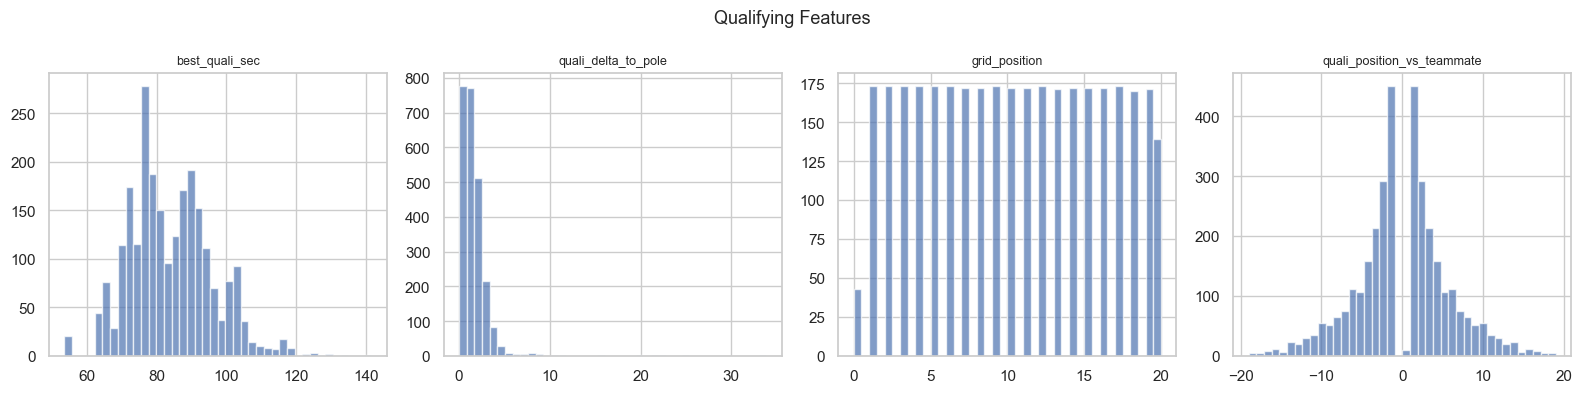

In [16]:
# Qualifying features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
quali_cols = ["best_quali_sec", "quali_delta_to_pole", "grid_position", "quali_position_vs_teammate"]
for ax, col in zip(axes, quali_cols):
    features_c[col].dropna().hist(bins=40, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
fig.suptitle("Qualifying Features", fontsize=13)
plt.tight_layout()
plt.show()

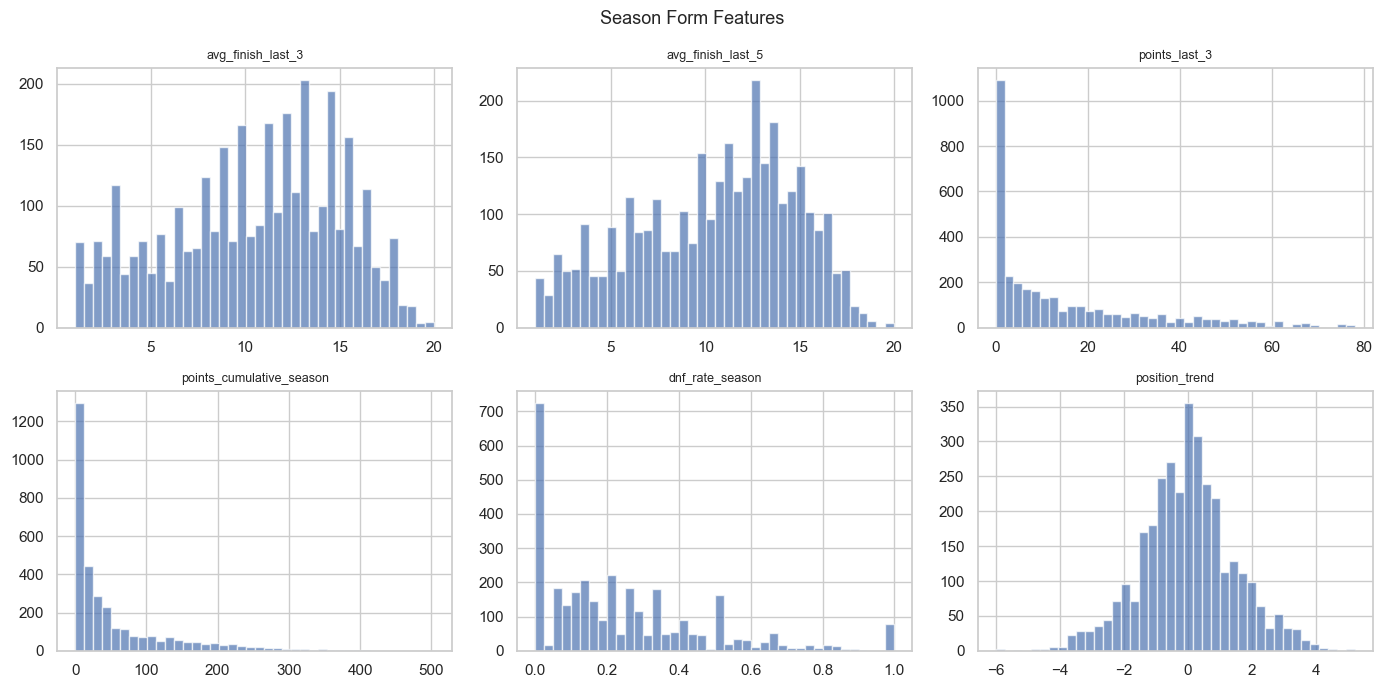

In [17]:
# Season form features
form_cols = ["avg_finish_last_3", "avg_finish_last_5", "points_last_3",
             "points_cumulative_season", "dnf_rate_season", "position_trend"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, form_cols):
    features_c[col].dropna().hist(bins=40, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
fig.suptitle("Season Form Features", fontsize=13)
plt.tight_layout()
plt.show()

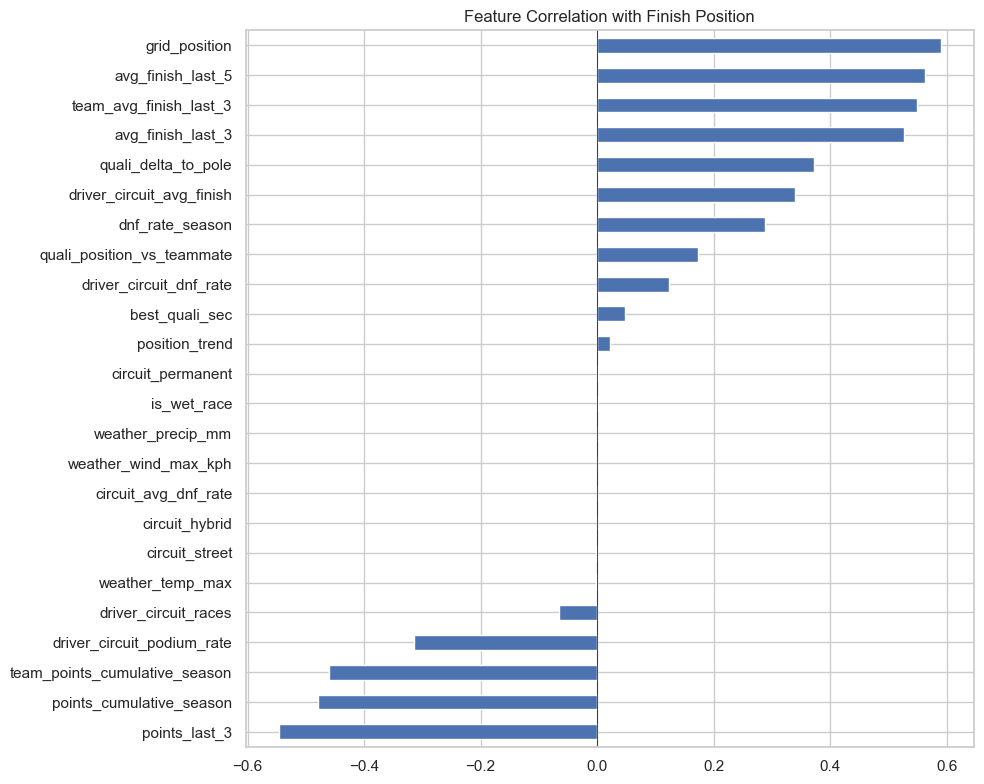

In [18]:
# Feature correlations with finish_position
numeric_c = features_c.select_dtypes(include=[np.number]).columns
feature_cols_c = [c for c in numeric_c
                  if c not in ["season", "round", "finish_position", "is_podium",
                               "is_points_finish", "is_dnf"]]
corr_with_target = features_c[feature_cols_c + ["finish_position"]].corr()["finish_position"].drop("finish_position")
corr_with_target = corr_with_target.dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot.barh(ax=ax)
ax.set_title("Feature Correlation with Finish Position")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Leakage audit: removing round 5 should not change round 3 features
audit_races = races[races["season"] == 2022].copy()
audit_full = build_race_features(audit_races)
audit_truncated = build_race_features(audit_races[audit_races["round"] <= 4].copy())

r3_full = audit_full[audit_full["round"] == 3].sort_values("driver_abbrev").reset_index(drop=True)
r3_trunc = audit_truncated[audit_truncated["round"] == 3].sort_values("driver_abbrev").reset_index(drop=True)

check_cols = ["avg_finish_last_3", "points_last_3", "points_cumulative_season", "dnf_rate_season"]
for col in check_cols:
    pd.testing.assert_series_equal(
        r3_full[col], r3_trunc[col], check_names=False, obj=col
    )
print("Leakage audit PASSED: future data does not affect past features.")

Leakage audit PASSED: future data does not affect past features.


In [20]:
# CV split preview
splitter_c = ExpandingWindowSplit()
groups_c = features_c["season"].values
print(f"Model C CV: {splitter_c.get_n_splits()} folds (expanding window)")
for i, (train_idx, val_idx) in enumerate(splitter_c.split(groups_c)):
    train_seasons = sorted(set(groups_c[train_idx]))
    val_seasons = sorted(set(groups_c[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_c.get_test_split(groups_c)
print(f"  Test: seasons={sorted(set(groups_c[test_idx]))} ({len(test_idx):,})")

Model C CV: 5 folds (expanding window)
  Fold 1: train=[np.int64(2018)] (420), val=[np.int64(2019)] (420)
  Fold 2: train=[np.int64(2018), np.int64(2019)] (840), val=[np.int64(2020)] (340)
  Fold 3: train=[np.int64(2018), np.int64(2019), np.int64(2020)] (1,180), val=[np.int64(2021)] (440)
  Fold 4: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] (1,620), val=[np.int64(2022)] (440)
  Fold 5: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (2,060), val=[np.int64(2023)] (440)
  Test: seasons=[np.int64(2025)] (479)


In [21]:
out_c = DATA_PROCESSED / "race" / "features_race.parquet"
features_c.to_parquet(out_c, index=False)
print(f"Saved: {out_c} ({out_c.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\race\features_race.parquet (111 KB)


## 5. Feature Selection by Model

Use Random Forest importance and correlation analysis to recommend which features each model should use during training.

In [22]:
def quick_rf_importance(X: pd.DataFrame, y: pd.Series, max_rows: int = 50_000) -> pd.Series:
    """Fit a quick RF and return feature importances."""
    mask = X.notna().all(axis=1) & y.notna()
    X_clean, y_clean = X[mask], y[mask]
    if len(X_clean) > max_rows:
        idx = np.random.default_rng(42).choice(len(X_clean), max_rows, replace=False)
        X_clean, y_clean = X_clean.iloc[idx], y_clean.iloc[idx]
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_clean, y_clean)
    return pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)


def find_redundant(X: pd.DataFrame, threshold: float = 0.85) -> pd.DataFrame:
    """Find feature pairs with absolute correlation above threshold."""
    corr_abs = X.corr().abs()
    mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
    pairs = corr_abs.where(mask).stack().reset_index()
    pairs.columns = ["feature_1", "feature_2", "correlation"]
    return pairs[pairs["correlation"] > threshold].sort_values("correlation", ascending=False)


def recommend_features(
    importance: pd.Series, redundant: pd.DataFrame, min_importance: float = 0.01
) -> list[str]:
    """Drop the less-important member of each redundant pair, then filter by importance."""
    drop = set()
    for _, row in redundant.iterrows():
        f1, f2 = row["feature_1"], row["feature_2"]
        if importance.get(f1, 0) < importance.get(f2, 0):
            drop.add(f1)
        else:
            drop.add(f2)
    return [f for f in importance.index if f not in drop and importance[f] >= min_importance]

### 5.1 Model A — Lap + Tyre Features

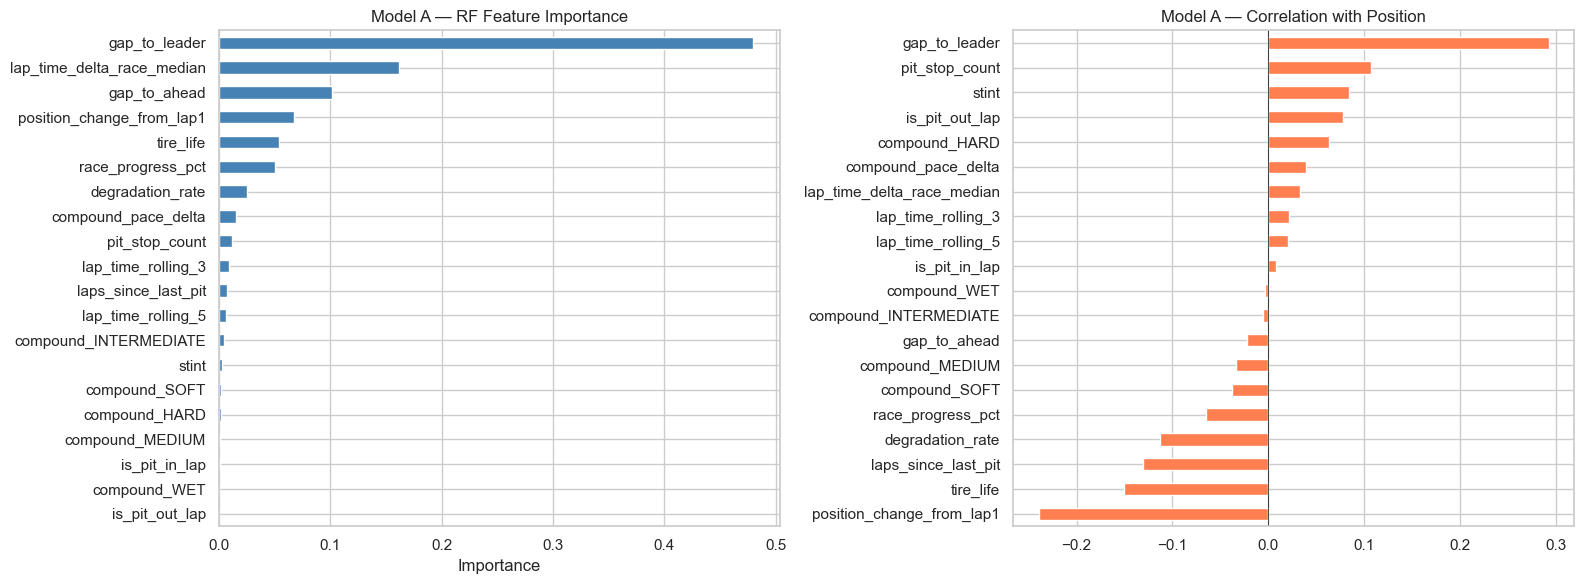

Redundant pairs (|r| > 0.85):
          feature_1          feature_2  correlation
laps_since_last_pit          tire_life     0.982832
     pit_stop_count              stint     0.981337
 lap_time_rolling_3 lap_time_rolling_5     0.964961

Recommended features for Model A (9/20):
  gap_to_leader                        importance=0.4798
  lap_time_delta_race_median           importance=0.1619
  gap_to_ahead                         importance=0.1015
  position_change_from_lap1            importance=0.0676
  tire_life                            importance=0.0536
  race_progress_pct                    importance=0.0505
  degradation_rate                     importance=0.0251
  compound_pace_delta                  importance=0.0153
  pit_stop_count                       importance=0.0115


In [23]:
ID_COLS_A = {"season", "round", "event_name", "driver_abbrev", "team", "lap_number"}
TARGET_A = "position"
feat_a = [c for c in features_a.columns if c not in ID_COLS_A | {TARGET_A}]

imp_a = quick_rf_importance(features_a[feat_a], features_a[TARGET_A])
redundant_a = find_redundant(features_a[feat_a])
recommended_a = recommend_features(imp_a, redundant_a)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_a.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Model A — RF Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()

corr_target_a = features_a[feat_a].corrwith(features_a[TARGET_A]).dropna().sort_values()
corr_target_a.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Model A — Correlation with Position")
axes[1].axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

if len(redundant_a):
    print("Redundant pairs (|r| > 0.85):")
    print(redundant_a.to_string(index=False))

print(f"\nRecommended features for Model A ({len(recommended_a)}/{len(feat_a)}):")
for f in recommended_a:
    print(f"  {f:35s}  importance={imp_a[f]:.4f}")

### 5.2 Model B — Lap Features (No Tyre)

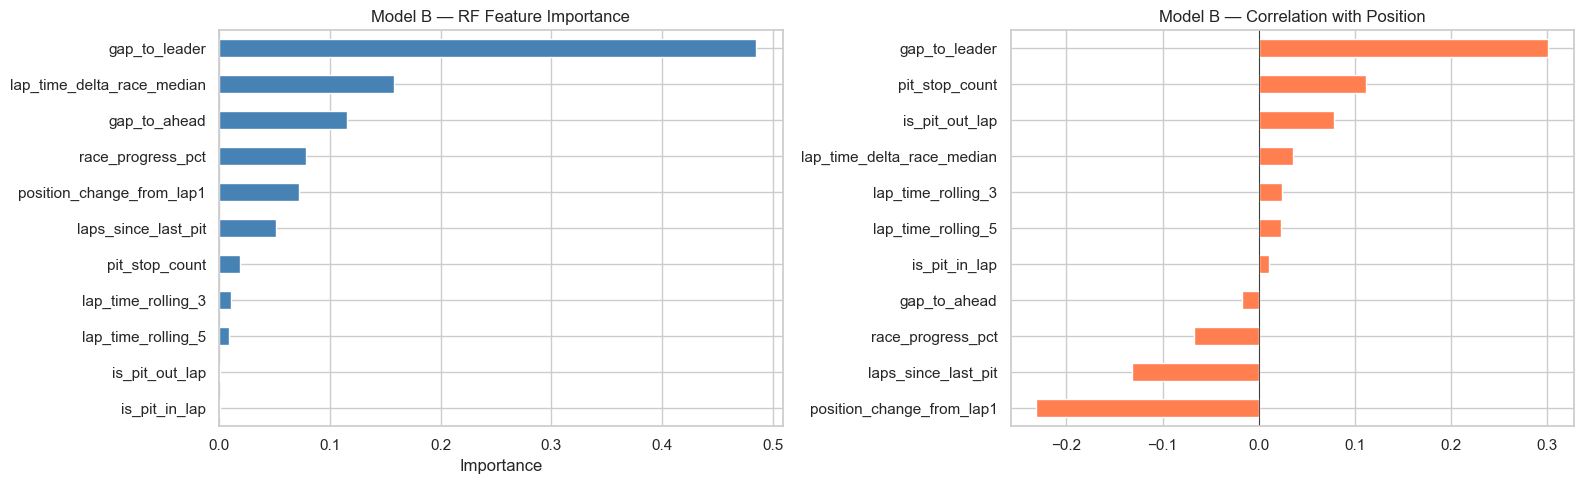

Redundant pairs (|r| > 0.85):
         feature_1          feature_2  correlation
lap_time_rolling_3 lap_time_rolling_5     0.965765

Recommended features for Model B (8/11):
  gap_to_leader                        importance=0.4846
  lap_time_delta_race_median           importance=0.1581
  gap_to_ahead                         importance=0.1156
  race_progress_pct                    importance=0.0788
  position_change_from_lap1            importance=0.0721
  laps_since_last_pit                  importance=0.0513
  pit_stop_count                       importance=0.0187
  lap_time_rolling_3                   importance=0.0108


In [24]:
ID_COLS_B = {"season", "round", "event_name", "driver_abbrev", "team", "lap_number"}
TARGET_B = "position"
feat_b = [c for c in features_b.columns if c not in ID_COLS_B | {TARGET_B}]

imp_b = quick_rf_importance(features_b[feat_b], features_b[TARGET_B])
redundant_b = find_redundant(features_b[feat_b])
recommended_b = recommend_features(imp_b, redundant_b)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

imp_b.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Model B — RF Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()

corr_target_b = features_b[feat_b].corrwith(features_b[TARGET_B]).dropna().sort_values()
corr_target_b.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Model B — Correlation with Position")
axes[1].axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

if len(redundant_b):
    print("Redundant pairs (|r| > 0.85):")
    print(redundant_b.to_string(index=False))

print(f"\nRecommended features for Model B ({len(recommended_b)}/{len(feat_b)}):")
for f in recommended_b:
    print(f"  {f:35s}  importance={imp_b[f]:.4f}")

### 5.3 Model C — Pre-Race Features

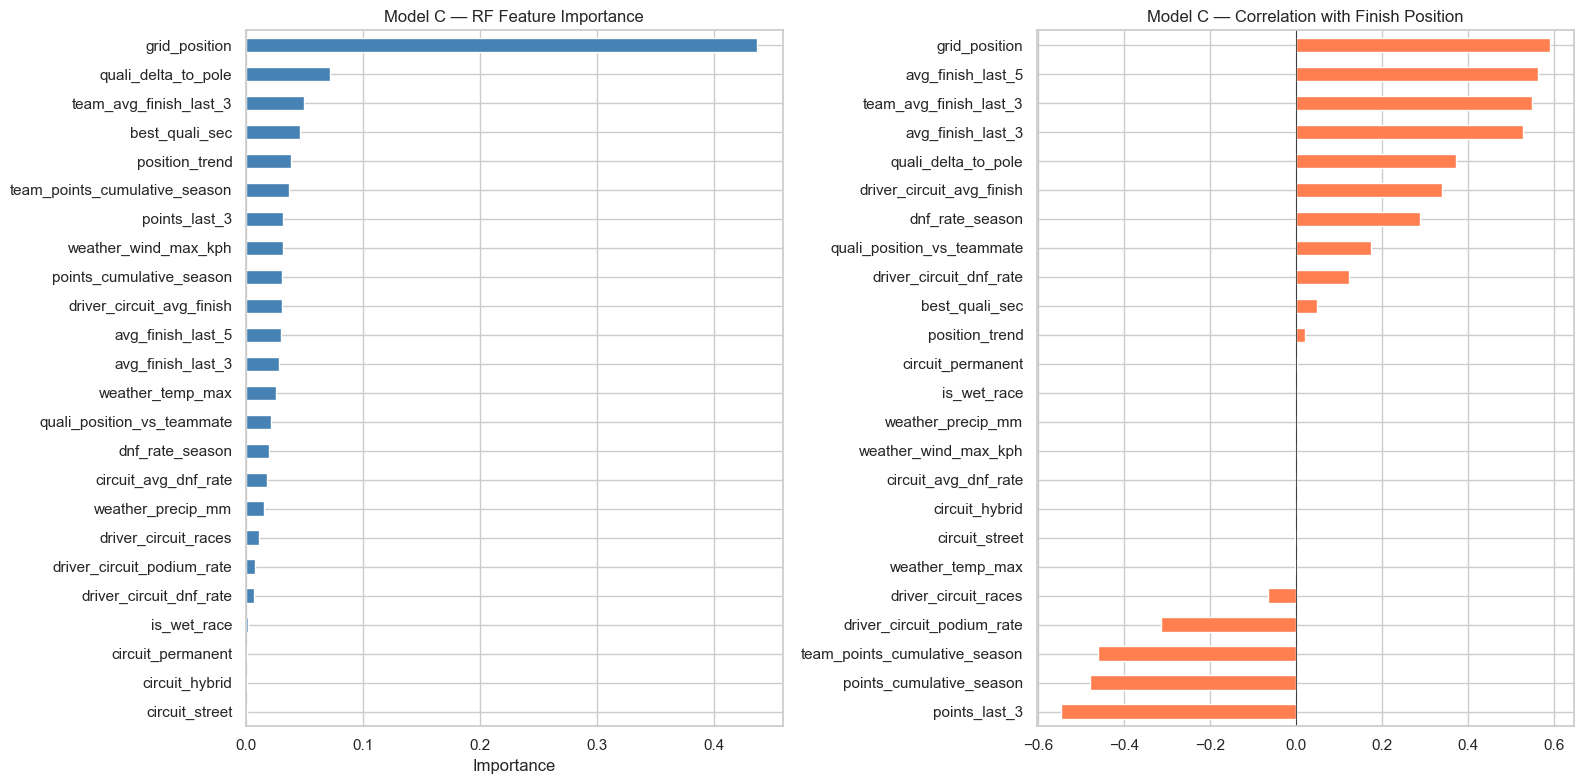

Redundant pairs (|r| > 0.85):
               feature_1                     feature_2  correlation
points_cumulative_season team_points_cumulative_season     0.945502
       avg_finish_last_3             avg_finish_last_5     0.934226
       avg_finish_last_3                 points_last_3     0.895525
       avg_finish_last_3        team_avg_finish_last_3     0.885846
       avg_finish_last_5                 points_last_3     0.878919
       avg_finish_last_5        team_avg_finish_last_3     0.864534

Features with >20% missing (consider imputation or dropping):
  driver_circuit_podium_rate           30.9% missing
  driver_circuit_dnf_rate              30.9% missing
  driver_circuit_avg_finish            30.9% missing
  driver_circuit_races                 30.9% missing
  best_quali_sec                       30.0% missing
  quali_delta_to_pole                  30.0% missing

Recommended features for Model C (15/24):
  grid_position                        importance=0.4372  missing=0.1%

In [25]:
ID_COLS_C = {"season", "round", "event_name", "driver_abbrev", "team"}
TARGETS_C = {"finish_position", "is_podium", "is_points_finish", "is_dnf"}
feat_c = [c for c in features_c.columns if c not in ID_COLS_C | TARGETS_C]

imp_c = quick_rf_importance(features_c[feat_c], features_c["finish_position"])
redundant_c = find_redundant(features_c[feat_c])
recommended_c = recommend_features(imp_c, redundant_c)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

imp_c.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Model C — RF Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()

corr_target_c = features_c[feat_c].corrwith(features_c["finish_position"]).dropna().sort_values()
corr_target_c.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Model C — Correlation with Finish Position")
axes[1].axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

if len(redundant_c):
    print("Redundant pairs (|r| > 0.85):")
    print(redundant_c.to_string(index=False))

# Missing value analysis for feature viability
missing_pct = features_c[feat_c].isnull().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.2]
if len(high_missing):
    print(f"\nFeatures with >20% missing (consider imputation or dropping):")
    for f, pct in high_missing.items():
        print(f"  {f:35s}  {pct:.1%} missing")

print(f"\nRecommended features for Model C ({len(recommended_c)}/{len(feat_c)}):")
for f in recommended_c:
    miss = features_c[f].isnull().mean()
    print(f"  {f:35s}  importance={imp_c[f]:.4f}  missing={miss:.1%}")

## 6. Model D — Stacking Meta-Model

Model D is a **stacking (meta-learning) ensemble** — it does not require its own feature engineering pipeline because its inputs are the *predictions* from Models A, B, and C, not raw F1 data.

**How it works:**
- **Level 1**: Models A (lap+tyre), B (lap, no tyre), and C (pre-race) each generate out-of-fold predictions during cross-validation
- **Level 2**: Model D takes those predictions as features and learns the optimal way to combine them

**Why no feature engineering?**
- Model D's "features" are the probability/position outputs from the first-level models
- These already encode all the signal from the raw features — the meta-model's job is to learn *how much to trust each model* in different situations
- Optionally, a few Model C features (e.g. `grid_position`, `is_wet_race`) can be passed through as context to help the meta-model weight predictions differently for street circuits vs. permanent circuits, wet vs. dry, etc.

**Implementation plan (JOW-15):**
1. Train Models A, B, C with cross-validation, collecting out-of-fold predictions
2. Stack predictions into a meta-feature matrix: `[pred_A, pred_B, pred_C, grid_position, is_wet_race, ...]`
3. Train Model D (e.g. Ridge regression or LightGBM) on the meta-features
4. For inference: run all Level 1 models, feed predictions to Model D for final output

## 7. Summary

In [26]:
print("Feature Engineering Summary")
print("=" * 60)
for name, df, path, rec in [
    ("Model A (lap+tyre)", features_a, out_a, recommended_a),
    ("Model B (lap, no tyre)", features_b, out_b, recommended_b),
    ("Model C (pre-race)", features_c, out_c, recommended_c),
]:
    size_kb = path.stat().st_size / 1024
    n_all = len([c for c in df.columns if c not in
                 ["season", "round", "event_name", "driver_abbrev", "team",
                  "lap_number", "position", "finish_position",
                  "is_podium", "is_points_finish", "is_dnf"]])
    print(f"\n{name}:")
    print(f"  Rows: {df.shape[0]:,}")
    print(f"  Total features: {n_all}")
    print(f"  Recommended features: {len(rec)}")
    print(f"  File: {path} ({size_kb:.0f} KB)")

print(f"\nModel D (stacking meta-model):")
print(f"  No feature engineering — uses predictions from Models A, B, C")

print("\n" + "=" * 60)
print("Next steps: JOW-15 (Model Training)")

Feature Engineering Summary

Model A (lap+tyre):
  Rows: 139,962
  Total features: 20
  Recommended features: 9
  File: ..\data\processed\lap_tyre\features_laps_tyre.parquet (5836 KB)

Model B (lap, no tyre):
  Rows: 165,128
  Total features: 11
  Recommended features: 8
  File: ..\data\processed\lap_notyre\features_laps_notyre.parquet (4842 KB)

Model C (pre-race):
  Rows: 3,458
  Total features: 24
  Recommended features: 15
  File: ..\data\processed\race\features_race.parquet (111 KB)

Model D (stacking meta-model):
  No feature engineering — uses predictions from Models A, B, C

Next steps: JOW-15 (Model Training)
